# Домашнее задание 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Numpy

### Создайте двумерный массив 5x5 с 1 на границе и 0 внутри.

In [ ]:
def border():
    a = np.zeros((5, 5), dtype=int)
    a[:1] = 1
    a[4:] = 1
    a[:, :1] = 1
    a[:, 4:] = 1
    return a

In [ ]:
border()

array([[1, 1, 1, 1, 1],
       [1, 0, 0, 0, 1],
       [1, 0, 0, 0, 1],
       [1, 0, 0, 0, 1],
       [1, 1, 1, 1, 1]])

### Создайте матрицу 8x8 и заполните ее шахматным узором.

In [ ]:
def checkerboard():
    a = np.tile([[1, 0], [0, 1]], (4, 4))
    return a

In [ ]:
checkerboard()

array([[1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 0, 1, 0, 1, 0, 1]])

### Вычтите из каждой строки матрицы среднее этой строки

In [ ]:
def sub():
    a = np.array([
        [1, 2, 3],
        [3, 4, 5],
        [6, 7, 8]
    ], dtype=int)
    return a - np.mean(a, axis=1, dtype=int).reshape((3, 1))

In [ ]:
sub()

array([[-1,  0,  1],
       [-1,  0,  1],
       [-1,  0,  1]])

### Как отсортировать матрицу по последней строке?

In [ ]:
def sort():
    a = np.array([
        [1, 2, 3],
        [3, 4, 5],
        [6, 7, 8]
    ])
    idx = np.argsort(a[-1])
    return a[:, idx]

In [ ]:
sort()

array([[1, 2, 3],
       [3, 4, 5],
       [6, 7, 8]])

## Pandas

In [ ]:
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age': [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

df = pd.DataFrame(data, index=labels)

### Выберите данные в 3, 4, 5 строчке колонок `animal` и `age`

In [ ]:
def animal_age(df):

    return df.loc[['c', 'd', 'e'], ['animal', 'age']]

In [ ]:
animal_age(df)

,animal,age
c,snake,0.5
d,dog,NaN
e,dog,5.0


### Выберите строки, где животное является котом и возраст меньше 3

In [ ]:
def cats(df):
    return df[np.logical_and(df['animal']== 'cat', df['age'] < 3)]

In [ ]:
cats(df)

,animal,age,visits,priority
a,cat,2.5,1,yes
f,cat,2.0,3,no


### Для каждого типа животного и количества посещений найдите средний возраст. Другими словами, каждая строка - это животное, каждый столбец - количество посещений, а значения - средний возраст

In [ ]:
def mean_table(df):
    result = df.pivot_table(
      index='animal',
      columns='visits',
      values='age',
      aggfunc='mean')


    return result

In [ ]:
mean_table(df)

visits,1,2,3
animal,,,
cat,2.5,NaN,2.5
dog,3.0,6.0,NaN
snake,4.5,0.5,NaN


### DataFrame имеет столбец групп 'grps' и столбец целочисленных значений 'vals'. Для каждой группы найдите сумму трех наибольших значений.

In [2]:
def threesome():
    data = {
        "grps": ["a", "a", "a", "a", "b", "b", "b", "b"],
        "vals": [100, 200, 109, 50, 23, 100, 33, 67],
    }
    df = pd.DataFrame(data)

    result = (df.groupby("grps")["vals"].nlargest(3).groupby("grps").sum().rename("vals"))

    return result

In [3]:
threesome()

,vals
grps,
a,409
b,200


## Matplotlib

Тут сложно написать тесты, так что надеюсь на вашу честность. Поставьте `True`, если вы сделали задание

### Нарисуйте пару смешных графиков для `df` (который с животными)
Это не дз по датавизу, если хотите - можем сделать такую пару

In [ ]:
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age': [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

df = pd.DataFrame(data, index=labels)

def plots(df):
    visits_by_animal = df.groupby('animal')['visits'].sum()

    # Стиль графика
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(
        visits_by_animal.index,
        visits_by_animal.values,
        color=['#FFD700', '#FF6347', '#7FFFD4'],
        edgecolor='black',
        linewidth=2
    )

    # Заголовок и подписи
    ax.set_title('Кто чаще всех ходит к ветеринару?\n(По количеству посещений)', fontsize=14, pad=20)
    ax.set_xlabel('Животные', fontsize=12)
    ax.set_ylabel('', fontsize=12)

    # Убираем рамку
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    return True

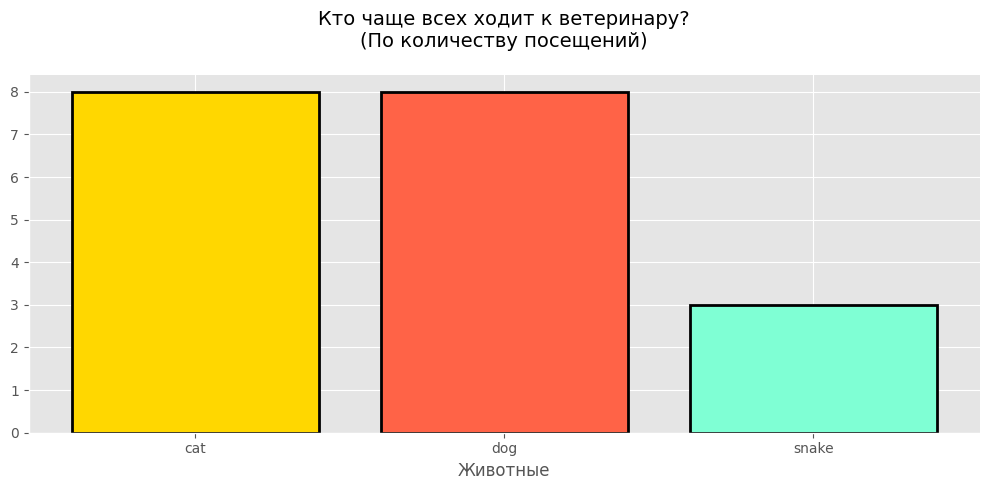

True

In [ ]:
plots(df)